In [ ]:
!pip install kagglehub torch torchvision pillow

import os
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import kagglehub

In [ ]:
path = kagglehub.dataset_download("wenewone/cub2002011")
print(path)

Using Colab cache for faster access to the 'cub2002011' dataset.
/kaggle/input/cub2002011


In [ ]:
def load_image_labels(data_path):
    data = {}

    file_path = os.path.join(data_path, "CUB_200_2011", "images.txt")

    with open(file_path, "r") as f:
        for line in f:
            _, img_path = line.strip().split()

            full_path = os.path.join(
                data_path, "CUB_200_2011", "images", img_path
            )

            img_name = img_path.split("/")[-1]
            class_name = img_path.split("/")[0].replace(".", " ")

            caption = f"a bird of type {class_name}"

            data[img_name] = (full_path, caption)

    return data

In [ ]:
class CUBDataset(Dataset):
    def __init__(self, data):
        self.data = list(data.values())

        self.transform = transforms.Compose([
            transforms.Resize((64, 64)),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])
        ])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, caption = self.data[idx]

        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)

        return image, caption

In [ ]:
def build_vocab(captions, vocab_size=5000):
    all_words = []

    for _, cap in captions.values():
        tokens = cap.lower().split()
        all_words.extend(tokens)

    freq = {}
    for word in all_words:
        freq[word] = freq.get(word, 0) + 1

    vocab = {word: i+1 for i, (word, _) in enumerate(sorted(freq.items(), key=lambda x: -x[1])[:vocab_size])}
    vocab["<pad>"] = 0

    return vocab


def encode_caption(caption, vocab, max_len=20):
    tokens = caption.lower().split()
    encoded = [vocab.get(word, 0) for word in tokens]

    if len(encoded) < max_len:
        encoded += [0] * (max_len - len(encoded))

    return encoded[:max_len]

In [ ]:
class TextEncoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, hidden_dim=256):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)

    def forward(self, x):
        x = self.embedding(x)
        _, (hidden, _) = self.lstm(x)
        return hidden.squeeze(0)

In [ ]:
class SelfAttention(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.query = nn.Conv2d(in_dim, in_dim//8, 1)
        self.key = nn.Conv2d(in_dim, in_dim//8, 1)
        self.value = nn.Conv2d(in_dim, in_dim, 1)
        self.gamma = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        B, C, H, W = x.size()

        query = self.query(x).view(B, -1, H*W).permute(0, 2, 1)
        key = self.key(x).view(B, -1, H*W)

        attention = torch.softmax(torch.bmm(query, key), dim=-1)

        value = self.value(x).view(B, -1, H*W)
        out = torch.bmm(value, attention.permute(0, 2, 1))

        out = out.view(B, C, H, W)
        return self.gamma * out + x

In [ ]:
class Generator(nn.Module):
    def __init__(self, noise_dim, text_dim):
        super().__init__()

        self.fc = nn.Linear(noise_dim + text_dim, 512*4*4)

        self.net = nn.Sequential(
    nn.BatchNorm2d(512),

    nn.ConvTranspose2d(512, 256, 4, 2, 1),  # 4 → 8
    nn.ReLU(),

    SelfAttention(256),

    nn.ConvTranspose2d(256, 128, 4, 2, 1),  # 8 → 16
    nn.ReLU(),

    SelfAttention(128),

    nn.ConvTranspose2d(128, 64, 4, 2, 1),   # 16 → 32
    nn.ReLU(),

    nn.ConvTranspose2d(64, 3, 4, 2, 1),     # 32 → 64 ✅
    nn.Tanh()
)

    def forward(self, noise, text_embed):
        x = torch.cat([noise, text_embed], dim=1)
        x = self.fc(x).view(-1, 512, 4, 4)
        return self.net(x)

In [ ]:
class Discriminator(nn.Module):
    def __init__(self, text_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.LeakyReLU(0.2),

            SelfAttention(128),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.LeakyReLU(0.2)
        )

        self.fc = nn.Linear(256*8*8 + text_dim, 1)

    def forward(self, img, text_embed):
        x = self.net(img)
        x = x.view(x.size(0), -1)
        x = torch.cat([x, text_embed], dim=1)
        return torch.sigmoid(self.fc(x))

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

data = load_image_labels(path)
vocab = build_vocab(data)

dataset = CUBDataset(data)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

text_encoder = TextEncoder(len(vocab)).to(device)
G = Generator(100, 256).to(device)
D = Discriminator(256).to(device)

criterion = nn.BCELoss()

opt_G = torch.optim.Adam(G.parameters(), lr=0.0002)
opt_D = torch.optim.Adam(D.parameters(), lr=0.0002)

for epoch in range(10):
    for imgs, caps in dataloader:

        imgs = imgs.to(device)

        encoded_caps = torch.tensor(
            [encode_caption(c, vocab) for c in caps]
        ).to(device)

        # Text embeddings
        text_embed = text_encoder(encoded_caps)
        text_embed_detached = text_embed.detach()

        real_labels = torch.ones(imgs.size(0), 1).to(device)
        fake_labels = torch.zeros(imgs.size(0), 1).to(device)

        # -------------------
        # 🔹 Train Discriminator
        # -------------------
        noise = torch.randn(imgs.size(0), 100).to(device)
        fake_imgs = G(noise, text_embed)

        loss_real = criterion(D(imgs, text_embed_detached), real_labels)
        loss_fake = criterion(D(fake_imgs.detach(), text_embed_detached), fake_labels)

        d_loss = loss_real + loss_fake

        opt_D.zero_grad()
        d_loss.backward()
        opt_D.step()

        # -------------------
        # 🔹 Train Generator (IMPORTANT FIX)
        # -------------------
        noise = torch.randn(imgs.size(0), 100).to(device)

        # ✅ REGENERATE fake images
        fake_imgs = G(noise, text_embed)

        g_loss = criterion(D(fake_imgs, text_embed), real_labels)

        opt_G.zero_grad()
        g_loss.backward()
        opt_G.step()

    print(f"Epoch {epoch} | D Loss: {d_loss.item()} | G Loss: {g_loss.item()}")

Epoch 0 | D Loss: 1.9311943423205453e-20 | G Loss: 45.350364685058594
Epoch 1 | D Loss: 9.934108646802997e-09 | G Loss: 44.95243453979492
Epoch 2 | D Loss: 9.934108646802997e-09 | G Loss: 44.665950775146484
Epoch 3 | D Loss: 2.980232949312267e-08 | G Loss: 44.49858856201172
Epoch 4 | D Loss: 5.434623153382848e-20 | G Loss: 44.25045394897461
Epoch 5 | D Loss: 9.934108646802997e-09 | G Loss: 44.06217575073242
Epoch 6 | D Loss: 1.0961899582659585e-19 | G Loss: 43.6529541015625
Epoch 7 | D Loss: 7.902291997471521e-34 | G Loss: 74.60588836669922
Epoch 8 | D Loss: 1.0220180148747182e-24 | G Loss: 55.33982849121094
Epoch 9 | D Loss: 1.0742555951575484e-24 | G Loss: 55.3969841003418


In [ ]:
noise = torch.randn(1, 100).to(device)
sample_text = "a red bird with black wings"

encoded = torch.tensor([encode_caption(sample_text, vocab)]).to(device)
text_embed = text_encoder(encoded)

generated_img = G(noise, text_embed)

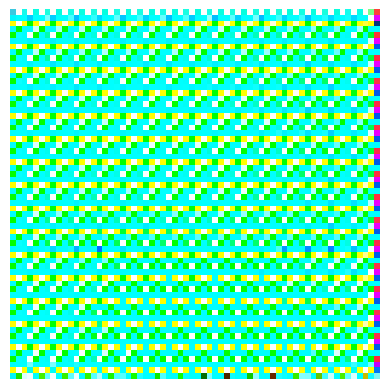

In [ ]:
import matplotlib.pyplot as plt

# Move to CPU and detach
img = generated_img.detach().cpu().squeeze(0)

# Convert from [-1, 1] → [0, 1]
img = (img + 1) / 2

# Convert to numpy
img = img.permute(1, 2, 0).numpy()

# Show image
plt.imshow(img)
plt.axis("off")
plt.show()